In [2]:
# ------------------------------------------------------------------ #
#  Notebook 05 · Market Basket Analysis                              #
#  Input : data/processed/retail_clean.parquet                       #
#  Output: data/processed/association_rules.parquet                  #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'
SAVE_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\association_rules.parquet'

In [3]:
df = pd.read_parquet(CLEAN_PATH)

# Focus on UK transactions only — international orders behave differently
# and including them would dilute the association patterns.
# Each basket is one invoice, each item is a product description.

basket = (
    df[df['Country'] == 'United Kingdom']
    .groupby(['Invoice', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
)

# Convert quantities to binary — we care about presence, not volume.
basket = basket.map(lambda x: 1 if x > 0 else 0)

print(f'Baskets (invoices) : {basket.shape[0]:,}')
print(f'Unique products    : {basket.shape[1]:,}')
print(f'Matrix density     : {basket.values.mean():.3%}')

Baskets (invoices) : 33,384
Unique products    : 5,242
Matrix density     : 0.394%


## 1. Apriori — Frequent Itemsets

Apriori finds products that appear together frequently across baskets.
`min_support` is the minimum fraction of baskets a product or combination
must appear in. With 33K baskets and 5,242 products, we set it at 2% to
keep computation tractable while still surfacing meaningful patterns.

In [6]:
# Restrict to the top 200 products by purchase frequency.
# Apriori complexity grows exponentially with number of columns —
# trimming to high-frequency products keeps memory manageable
# while covering the most actionable product combinations.

top_products = (
    df[df['Country'] == 'United Kingdom']
    .groupby('Description')['Invoice']
    .nunique()
    .nlargest(200)
    .index
)

basket_filtered = basket[top_products]

print(f'Filtered basket shape : {basket_filtered.shape}')
print(f'Matrix density        : {basket_filtered.values.mean():.3%}')

frequent_itemsets = apriori(
    basket_filtered,
    min_support=0.01,
    use_colnames=True,
    max_len=2
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'\nFrequent itemsets : {len(frequent_itemsets):,}')
print(f'Pairs             : {(frequent_itemsets["length"] == 2).sum()}')

Filtered basket shape : (33384, 200)
Matrix density        : 2.916%

Frequent itemsets : 361
Pairs             : 161


## 2. Association Rules

From the frequent itemsets we derive association rules using lift as the
metric. Lift measures how much more likely two products are to be bought
together compared to if they were purchased independently.

- **Support**    : fraction of baskets containing both items
- **Confidence** : given the antecedent, how often the consequent appears
- **Lift**       : ratio of observed co-occurrence to expected by chance — lift > 1 means positively correlated

In [9]:
# Pass the full frequent_itemsets dataframe so mlxtend can look up
# individual item support values when computing confidence and lift.

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=3.0,
    num_itemsets=len(frequent_itemsets)
)

rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Convert frozensets to readable strings for display and saving
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f'Rules generated : {len(rules)}')
print(f'Avg lift        : {rules["lift"].mean():.2f}')
print(f'Max lift        : {rules["lift"].max():.2f}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Rules generated : 268
Avg lift        : 11.70
Max lift        : 33.84


,antecedents,consequents,support,confidence,lift
0,FELTCRAFT CUSHION RABBIT,FELTCRAFT CUSHION BUTTERFLY,0.012791,0.658951,33.843704
1,FELTCRAFT CUSHION BUTTERFLY,FELTCRAFT CUSHION RABBIT,0.012791,0.656923,33.843704
2,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.016475,0.664251,33.497526
3,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.016475,0.830816,33.497526
4,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.013719,0.730463,32.864907
5,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.013719,0.617251,32.864907
6,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.015786,0.572826,28.887048
7,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.015786,0.796073,28.887048
8,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.019710,0.715217,28.836736
9,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.019710,0.794686,28.836736


## 3. Visualisation

We plot the top rules by lift and a support vs confidence scatter
to understand the distribution of rule quality across all 268 rules.

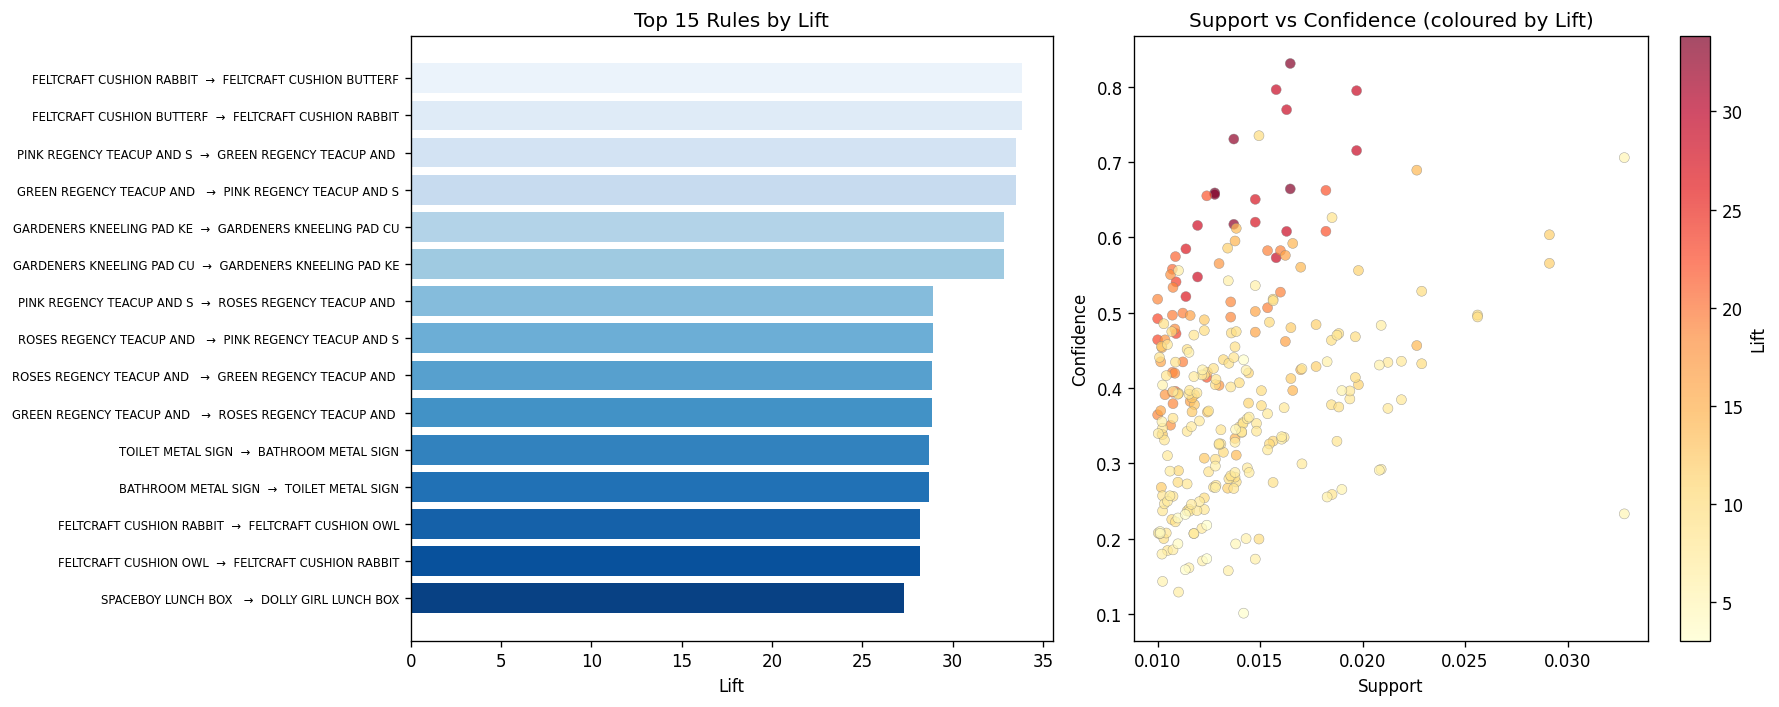

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 rules by lift
top_rules = rules.head(15).copy()
top_rules['label'] = top_rules['antecedents'].str[:25] + '  →  ' + top_rules['consequents'].str[:25]
top_rules = top_rules.sort_values('lift')

axes[0].barh(
    top_rules['label'],
    top_rules['lift'],
    color=sns.color_palette('Blues_r', len(top_rules))
)
axes[0].set_title('Top 15 Rules by Lift')
axes[0].set_xlabel('Lift')
axes[0].tick_params(axis='y', labelsize=7)

# Support vs confidence scatter coloured by lift
sc = axes[1].scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='grey',
    linewidths=0.3
)
plt.colorbar(sc, ax=axes[1], label='Lift')
axes[1].set_title('Support vs Confidence (coloured by Lift)')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')

plt.tight_layout()
plt.show()

## 4. Save Rules

In [11]:
# Round metrics to 4 decimal places for cleaner storage and display.
rules['support']    = rules['support'].round(4)
rules['confidence'] = rules['confidence'].round(4)
rules['lift']       = rules['lift'].round(4)

rules.to_parquet(SAVE_PATH, index=False)

print(f'Saved : {SAVE_PATH}')
print(f'Rows  : {len(rules)}')
print(f'Columns: {rules.columns.tolist()}')

Saved : E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\association_rules.parquet
Rows  : 268
Columns: ['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']
